# Обнаружение аномалий в данных

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Фиксируем значение для Random State
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Загрузка данных
df = pd.read_csv('skab_valve_1.csv', sep=';', parse_dates=['datetime'])
print("Данные успешно загружены!")
print(f"Размер датасета: {df.shape}")
print("\nПервые 5 строк:")
print(df.head())
print("\nИнформация о данных:")
print(df.info())
print("\nСтатистики числовых признаков:")
print(df.describe())

Данные успешно загружены!
Размер датасета: (1094, 11)

Первые 5 строк:
             datetime  Accelerometer1RMS  Accelerometer2RMS  Current  \
0 2020-03-09 12:34:37           0.028030           0.040400  1.18285   
1 2020-03-09 12:34:38           0.026952           0.038880  1.45268   
2 2020-03-09 12:34:39           0.027958           0.040660  1.02300   
3 2020-03-09 12:34:40           0.027277           0.040736  1.22751   
4 2020-03-09 12:34:41           0.027210           0.039489  1.21526   

   Pressure  Temperature  Thermocouple  Voltage  Volume Flow RateRMS  anomaly  \
0  0.054711      69.9219       24.9122  229.918              32.9875      0.0   
1 -0.273216      69.9147       24.9038  219.566              32.0129      0.0   
2  0.054711      69.8861       24.9055  237.717              32.9875      0.0   
3 -0.273216      69.8397       24.9110  227.621              32.0000      0.0   
4 -0.273216      69.9136       24.9110  221.634              32.0129      0.0   

   change

Количество нормальных наблюдений: 689
Количество аномальных наблюдений: 405
Процент аномалий: 37.02%


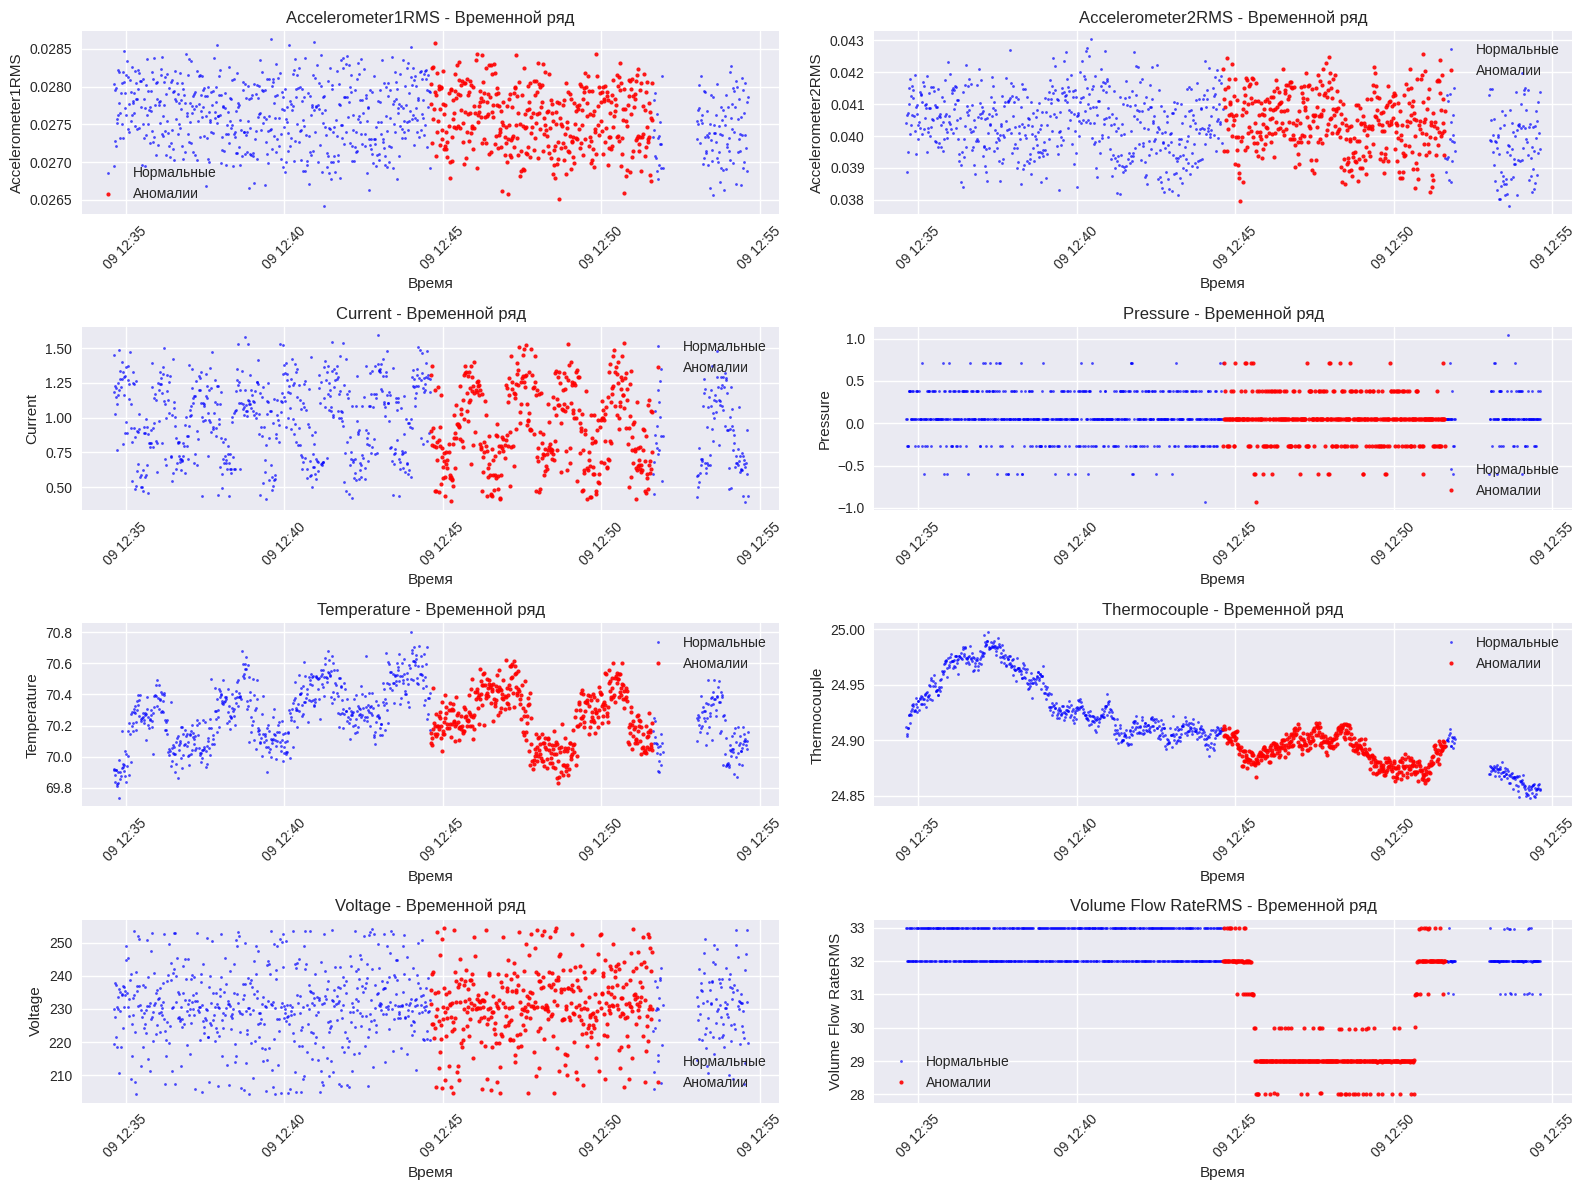


Распределение аномалий по времени:
count                              405
mean     2020-03-09 12:48:07.222222336
min                2020-03-09 12:44:37
25%                2020-03-09 12:46:22
50%                2020-03-09 12:48:07
75%                2020-03-09 12:49:52
max                2020-03-09 12:51:37
Name: datetime, dtype: object

Первые 5 аномальных наблюдений:
               datetime  Accelerometer1RMS  Accelerometer2RMS   Current  \
578 2020-03-09 12:44:37           0.028039           0.042091  0.902599   
579 2020-03-09 12:44:38           0.027774           0.041174  1.306780   
580 2020-03-09 12:44:39           0.027248           0.039537  0.800995   
581 2020-03-09 12:44:40           0.028246           0.040894  1.368380   
582 2020-03-09 12:44:41           0.028257           0.041473  0.859917   

     Pressure  Temperature  Thermocouple  Voltage  Volume Flow RateRMS  \
578 -0.273216      70.1531       24.9100  231.508              32.0000   
579  0.710565      70.0909   

In [43]:
# Создаем графики для каждого признака с выделением аномалий
features = ['Accelerometer1RMS', 'Accelerometer2RMS', 'Current', 'Pressure',
           'Temperature', 'Thermocouple', 'Voltage', 'Volume Flow RateRMS']

normal_data = df[df['anomaly'] == 0]
anomaly_data = df[df['anomaly'] == 1]

print(f"Количество нормальных наблюдений: {len(normal_data)}")
print(f"Количество аномальных наблюдений: {len(anomaly_data)}")
print(f"Процент аномалий: {len(anomaly_data)/len(df)*100:.2f}%")

# Создаем график со всеми признаками
fig, axes = plt.subplots(4, 2, figsize=(16, 12))
axes = axes.ravel()

for i, feature in enumerate(features):
    axes[i].plot(normal_data['datetime'], normal_data[feature],
                'o', markersize=2, alpha=0.7, label='Нормальные', color='blue')

    axes[i].plot(anomaly_data['datetime'], anomaly_data[feature],
                'o', markersize=3, alpha=0.9, label='Аномалии', color='red')

    axes[i].set_title(f'{feature} - Временной ряд')
    axes[i].set_xlabel('Время')
    axes[i].set_ylabel(feature)
    axes[i].legend()
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("\nРаспределение аномалий по времени:")
anomaly_time_stats = anomaly_data['datetime'].describe()
print(anomaly_time_stats)

print("\nПервые 5 аномальных наблюдений:")
print(anomaly_data.head())

## Визуализация исходных данных

На графиках показаны временные ряды датчиков. Красным отмечены аномальные точки (anomaly = 1), соответствующие отклонению в поведении системы. По графикам можно заметить, что аномалии встречаются неравномерно и могут быть связаны с резкими скачками в температуре и давлении.


## Метод 1: Статистические эвристики (IQR)

Первый подход — использование IQR.  
Для каждого признака рассчитываем:
- нижнюю границу: `Q1 - k * IQR`,
- верхнюю границу: `Q3 + k * IQR`.

Используем два порога:
- `k = 1.5` — чувствительный, может давать ложные срабатывания;
- `k = 3` — строгий, но устойчивый к шуму.

IQR используется потому что метод простой и не требует обучения модели, он хорошо подходит, если распределение признаков близко к нормальному. IQR позволяет быстро оценить выбросы на уровне каждого признака и задать чувствительность через множитель (1.5 или 3).

Обнаружение аномалий методом IQR
Аномалий с IQR*1.5: 105
Аномалий с IQR*3.0: 2

Качество обнаружения (IQR*1.5)
              precision    recall  f1-score   support

  Нормальные       0.63      0.90      0.74       689
    Аномалии       0.34      0.09      0.14       405

    accuracy                           0.60      1094
   macro avg       0.48      0.49      0.44      1094
weighted avg       0.52      0.60      0.52      1094


Качество обнаружения (IQR*3.0)
              precision    recall  f1-score   support

  Нормальные       0.63      1.00      0.77       689
    Аномалии       0.50      0.00      0.00       405

    accuracy                           0.63      1094
   macro avg       0.57      0.50      0.39      1094
weighted avg       0.58      0.63      0.49      1094



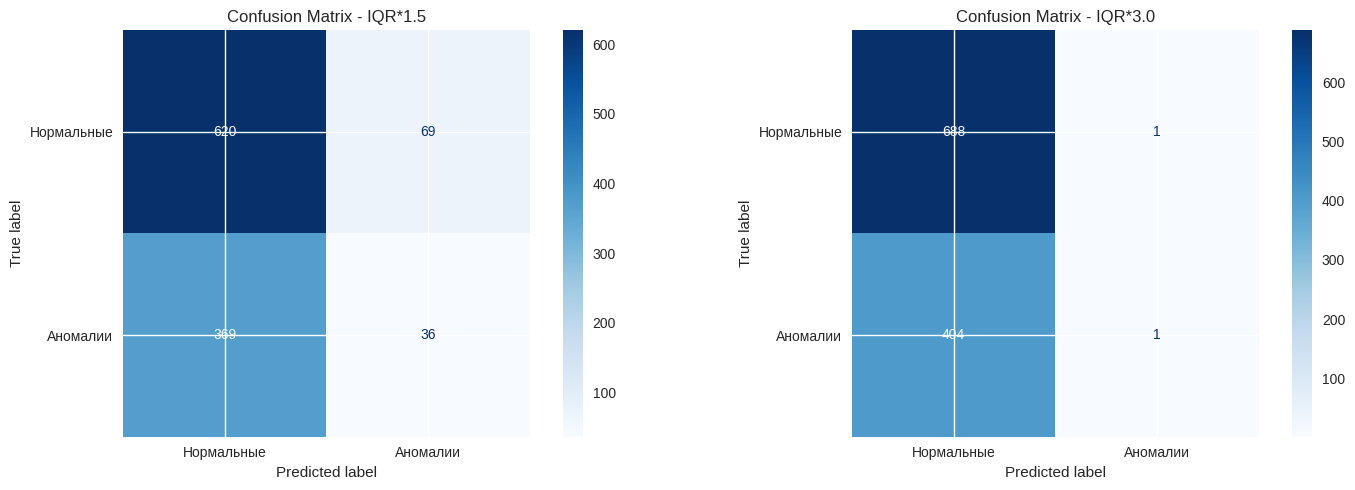


Распределение аномалий по признакам (IQR*1.5)
Accelerometer1RMS: 0 аномалий
Accelerometer2RMS: 0 аномалий
Current: 0 аномалий
Pressure: 76 аномалий
Temperature: 0 аномалий
Thermocouple: 3 аномалий
Voltage: 30 аномалий
Volume Flow RateRMS: 0 аномалий

Всего уникальных аномальных наблюдений: 105


In [44]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Функция для обнаружения аномалий методом IQR
def detect_anomalies_iqr(data, features, multiplier=1.5):
    anomalies = pd.DataFrame(index=data.index)

    for feature in features:
        Q1 = data[feature].quantile(0.25)
        Q3 = data[feature].quantile(0.75)
        IQR = Q3 - Q1

        lower_bound = Q1 - multiplier * IQR
        upper_bound = Q3 + multiplier * IQR

        anomalies[f'{feature}_anomaly'] = ((data[feature] < lower_bound) |
                                          (data[feature] > upper_bound)).astype(int)

    anomalies['total_anomalies'] = anomalies.sum(axis=1)

    anomalies['is_anomaly'] = (anomalies['total_anomalies'] > 0).astype(int)

    return anomalies

# Применяем метод IQR с разными множителями
print("Обнаружение аномалий методом IQR")

anomalies_iqr_15 = detect_anomalies_iqr(df, features, multiplier=1.5)
print(f"Аномалий с IQR*1.5: {anomalies_iqr_15['is_anomaly'].sum()}")

anomalies_iqr_3 = detect_anomalies_iqr(df, features, multiplier=3.0)
print(f"Аномалий с IQR*3.0: {anomalies_iqr_3['is_anomaly'].sum()}")

true_anomalies = df['anomaly']

# Оценка качества
print("\nКачество обнаружения (IQR*1.5)")
print(classification_report(true_anomalies, anomalies_iqr_15['is_anomaly'],
                          target_names=['Нормальные', 'Аномалии']))

print("\nКачество обнаружения (IQR*3.0)")
print(classification_report(true_anomalies, anomalies_iqr_3['is_anomaly'],
                          target_names=['Нормальные', 'Аномалии']))

# Визуализация confusion matrix
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

cm1 = confusion_matrix(true_anomalies, anomalies_iqr_15['is_anomaly'])
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=['Нормальные', 'Аномалии'])
disp1.plot(ax=ax1, cmap='Blues')
ax1.set_title('Confusion Matrix - IQR*1.5')

cm2 = confusion_matrix(true_anomalies, anomalies_iqr_3['is_anomaly'])
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=['Нормальные', 'Аномалии'])
disp2.plot(ax=ax2, cmap='Blues')
ax2.set_title('Confusion Matrix - IQR*3.0')

plt.tight_layout()
plt.show()

print("\nРаспределение аномалий по признакам (IQR*1.5)")
for feature in features:
    feature_anomalies = anomalies_iqr_15[f'{feature}_anomaly'].sum()
    print(f"{feature}: {feature_anomalies} аномалий")

print(f"\nВсего уникальных аномальных наблюдений: {anomalies_iqr_15['is_anomaly'].sum()}")

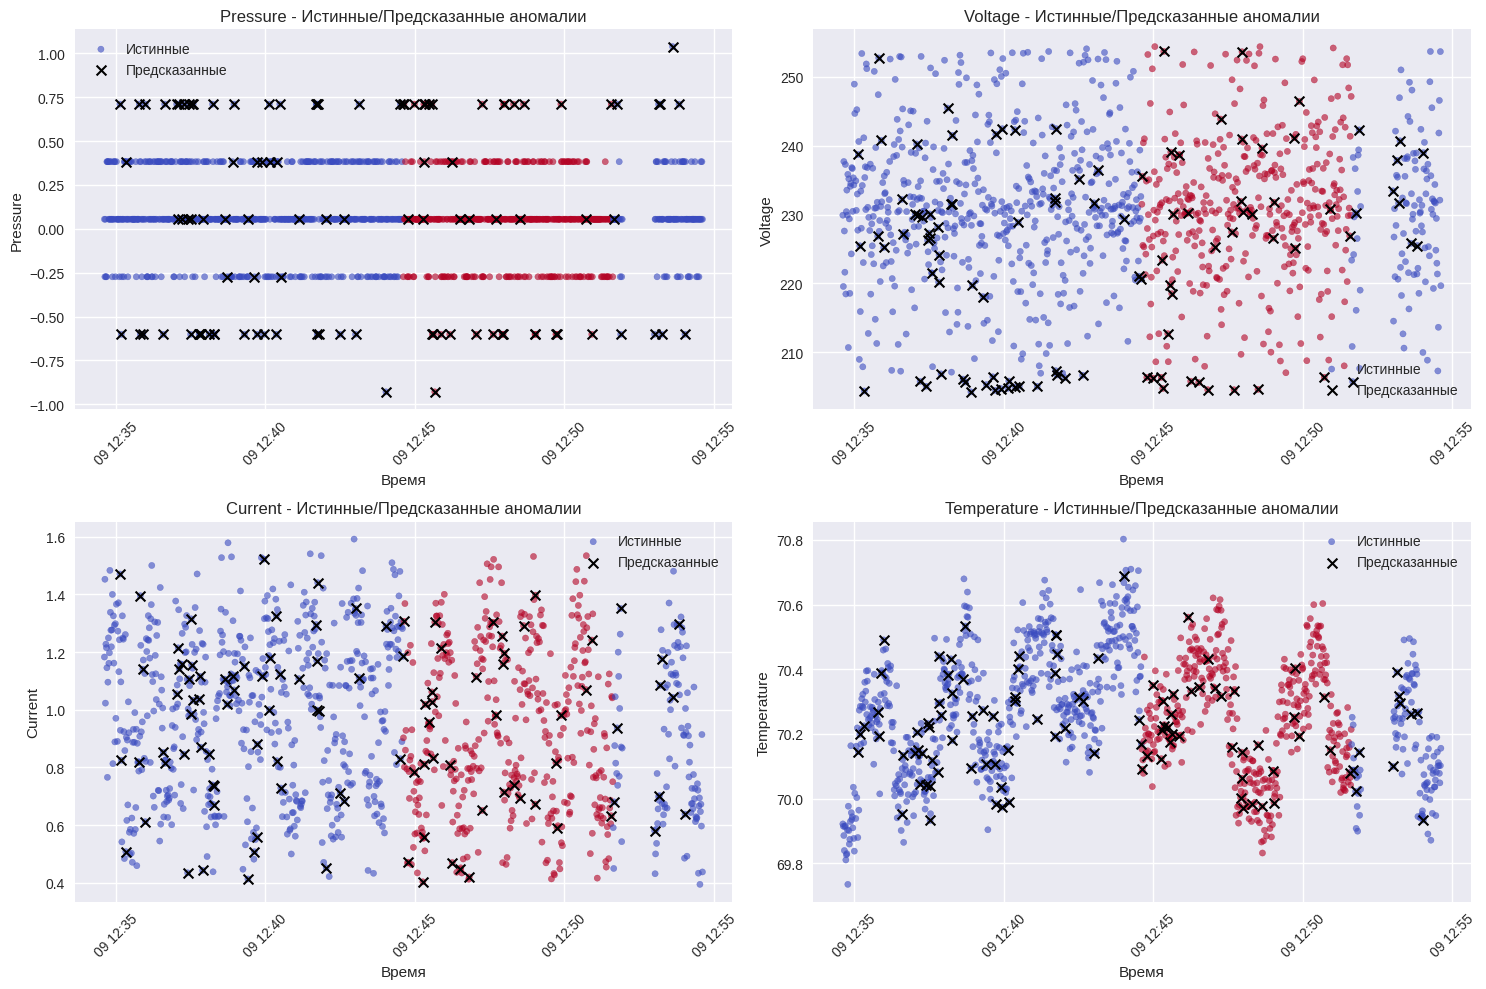

Accelerometer1RMS: Не обнаружено
Accelerometer2RMS: Не обнаружено
Current: Не обнаружено
Pressure: TP=27, FP=49, Precision=0.355
Temperature: Не обнаружено
Thermocouple: TP=0, FP=3, Precision=0.000
Voltage: TP=10, FP=20, Precision=0.333
Volume Flow RateRMS: Не обнаружено

Сравнение статистик нормальных и аномальных данных

Pressure:
Нормальные - mean: 0.079, std: 0.274
Аномалии  - mean: 0.043, std: 0.266

Voltage:
Нормальные - mean: 230.637, std: 10.972
Аномалии  - mean: 230.944, std: 10.684

Current:
Нормальные - mean: 0.980, std: 0.274
Аномалии  - mean: 0.927, std: 0.282


In [45]:
# Визуализируем результаты IQR метода
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

viz_features = ['Pressure', 'Voltage', 'Current', 'Temperature']

for i, feature in enumerate(viz_features):
    axes[i].scatter(df['datetime'], df[feature],
                   c=df['anomaly'], cmap='coolwarm', alpha=0.6, s=20, label='Истинные')

    predicted_anomalies = df.loc[anomalies_iqr_15['is_anomaly'] == 1]
    axes[i].scatter(predicted_anomalies['datetime'], predicted_anomalies[feature],
                   color='black', marker='x', s=50, linewidth=1.5, label='Предсказанные')

    axes[i].set_title(f'{feature} - Иcтинные/Предсказанные аномалии')
    axes[i].set_xlabel('Время')
    axes[i].set_ylabel(feature)
    axes[i].legend()
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

for feature in features:
    true_positives = ((anomalies_iqr_15[f'{feature}_anomaly'] == 1) & (df['anomaly'] == 1)).sum()
    false_positives = ((anomalies_iqr_15[f'{feature}_anomaly'] == 1) & (df['anomaly'] == 0)).sum()
    total_detected = anomalies_iqr_15[f'{feature}_anomaly'].sum()

    if total_detected > 0:
        precision = true_positives / total_detected
        print(f"{feature}: TP={true_positives}, FP={false_positives}, Precision={precision:.3f}")
    else:
        print(f"{feature}: Не обнаружено")

# Сравнение распределений для нормальных и аномальных данных
print("\nСравнение статистик нормальных и аномальных данных")
for feature in ['Pressure', 'Voltage', 'Current']:
    normal_stats = df[df['anomaly'] == 0][feature].describe()
    anomaly_stats = df[df['anomaly'] == 1][feature].describe()

    print(f"\n{feature}:")
    print(f"Нормальные - mean: {normal_stats['mean']:.3f}, std: {normal_stats['std']:.3f}")
    print(f"Аномалии  - mean: {anomaly_stats['mean']:.3f}, std: {anomaly_stats['std']:.3f}")

### Анализ результатов

По confusion matrix видно, что IQR с порогом 1.5 лучше находит аномалии,  
но имеет больше ложных срабатываний. При пороге 3 ошибок меньше, но часть аномалий пропадает.

Для визуализации выбраны признаки `Pressure`, `Voltage`, `Current`, `Temperature`, так как они напрямую отражают состояние оборудования и наиболее подходящие для анализа

## Метод 2: Кластеризация (KMeans / DBSCAN)

Теперь используем кластеризации.  
Для этого создадим новые признаки:
- статистики по окнам (скользящее среднее, стандартное отклонение),
- лаги временного ряда,
- временные признаки (день, час и т.п.).

## Почему выбраны методы KMeans и DBSCAN

KMeans хорошо работает при компактных и сферических кластерах. DBSCAN, напротив, не требует заранее задавать число кластеров и автоматически выделяет выбросы как шум.  
Оба метода позволяют выделить нормальные режимы как кластеры, а аномалии как точки, не принадлежащие ни одному кластеру.

Создание расширенных признаков
Исходное количество признаков: 11
После feature engineering: 74

Количество признаков для кластеризации: 67

Примеры созданных признаков:
['Accelerometer1RMS', 'Accelerometer2RMS', 'Current', 'Pressure', 'Temperature', 'Thermocouple', 'Voltage', 'Volume Flow RateRMS', 'Accelerometer1RMS_lag1', 'Accelerometer1RMS_lag3', 'Accelerometer1RMS_diff1', 'Accelerometer2RMS_lag1', 'Accelerometer2RMS_lag3', 'Accelerometer2RMS_diff1', 'Current_lag1', 'Current_lag3', 'Current_diff1', 'Pressure_lag1', 'Pressure_lag3', 'Pressure_diff1']

Размерность данных после стандартизации: (1094, 67)


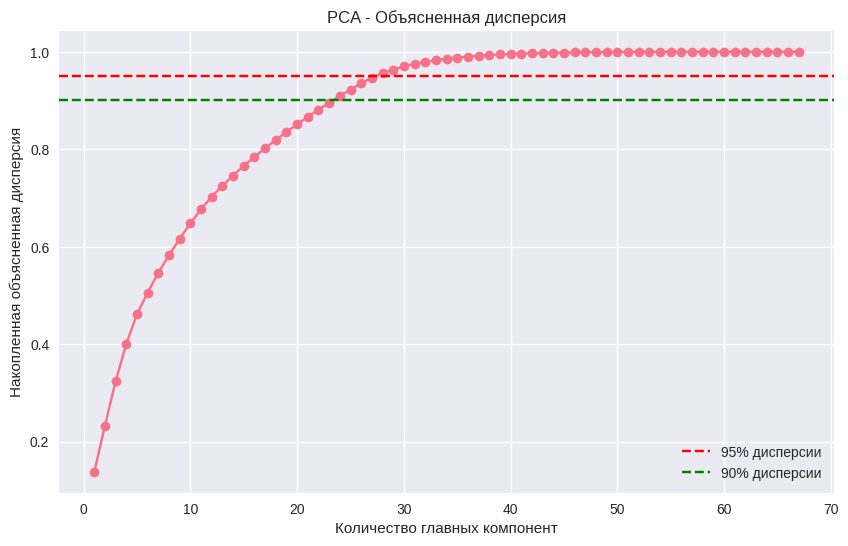

Количество компонент для 95% дисперсии: 28
Количество компонент для 90% дисперсии: 24

Данные подготовлены для кластеризации. Размерность: (1094, 67)


In [46]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Создаем расширенные признаки
def create_features(df, window_size=5):
    """
    Создание расширенных признаков для временного ряда
    """
    features_df = df.copy()

    numerical_features = ['Accelerometer1RMS', 'Accelerometer2RMS', 'Current',
                         'Pressure', 'Temperature', 'Thermocouple', 'Voltage',
                         'Volume Flow RateRMS']

    features_df['hour'] = features_df['datetime'].dt.hour
    features_df['minute'] = features_df['datetime'].dt.minute
    features_df['second'] = features_df['datetime'].dt.second
    features_df['time_of_day'] = features_df['hour'] * 3600 + features_df['minute'] * 60 + features_df['second']

    # Сдвиги
    for feature in numerical_features:
        features_df[f'{feature}_lag1'] = features_df[feature].shift(1)
        features_df[f'{feature}_lag3'] = features_df[feature].shift(3)
        features_df[f'{feature}_diff1'] = features_df[feature].diff(1)

    # Скользящие статистики
    for feature in numerical_features:
        features_df[f'{feature}_rolling_mean'] = features_df[feature].rolling(
            window=window_size, center=True).mean()
        features_df[f'{feature}_rolling_std'] = features_df[feature].rolling(
            window=window_size, center=True).std()
        features_df[f'{feature}_rolling_min'] = features_df[feature].rolling(
            window=window_size, center=True).min()
        features_df[f'{feature}_rolling_max'] = features_df[feature].rolling(
            window=window_size, center=True).max()

    # Взаимодействия признаков
    features_df['accel_product'] = features_df['Accelerometer1RMS'] * features_df['Accelerometer2RMS']
    features_df['power_approx'] = features_df['Current'] * features_df['Voltage']
    features_df['temp_diff'] = features_df['Temperature'] - features_df['Thermocouple']

    features_df = features_df.fillna(method='bfill').fillna(method='ffill')

    return features_df

print("Создание расширенных признаков")
enhanced_df = create_features(df)
print(f"Исходное количество признаков: {len(df.columns)}")
print(f"После feature engineering: {len(enhanced_df.columns)}")

feature_columns = [col for col in enhanced_df.columns
                  if col not in ['datetime', 'anomaly', 'changepoint']
                  and enhanced_df[col].dtype in ['float64', 'int64']]

print(f"\nКоличество признаков для кластеризации: {len(feature_columns)}")
print("\nПримеры созданных признаков:")
print(feature_columns[:20])

# Стандартизация данных
scaler = StandardScaler()
X_scaled = scaler.fit_transform(enhanced_df[feature_columns])

print(f"\nРазмерность данных после стандартизации: {X_scaled.shape}")

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1),
         np.cumsum(pca.explained_variance_ratio_), marker='o')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% дисперсии')
plt.axhline(y=0.90, color='g', linestyle='--', label='90% дисперсии')
plt.xlabel('Количество главных компонент')
plt.ylabel('Накопленная объясненная дисперсия')
plt.title('PCA - Объясненная дисперсия')
plt.legend()
plt.grid(True)
plt.show()

print(f"Количество компонент для 95% дисперсии: {np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.95) + 1}")
print(f"Количество компонент для 90% дисперсии: {np.argmax(np.cumsum(pca.explained_variance_ratio_) >= 0.90) + 1}")

X_prepared = X_scaled
print(f"\nДанные подготовлены для кластеризации. Размерность: {X_prepared.shape}")

Обнаружение аномалий методом кластеризации
DBSCAN - обнаружено аномалий: 1094
KMeans - обнаружено аномалий: 55

Качество обнаружения (DBSCAN)
              precision    recall  f1-score   support

  Нормальные       0.00      0.00      0.00       689
    Аномалии       0.37      1.00      0.54       405

    accuracy                           0.37      1094
   macro avg       0.19      0.50      0.27      1094
weighted avg       0.14      0.37      0.20      1094

Качество обнаружения (KMeans)
              precision    recall  f1-score   support

  Нормальные       0.62      0.94      0.75       689
    Аномалии       0.24      0.03      0.06       405

    accuracy                           0.60      1094
   macro avg       0.43      0.49      0.40      1094
weighted avg       0.48      0.60      0.49      1094



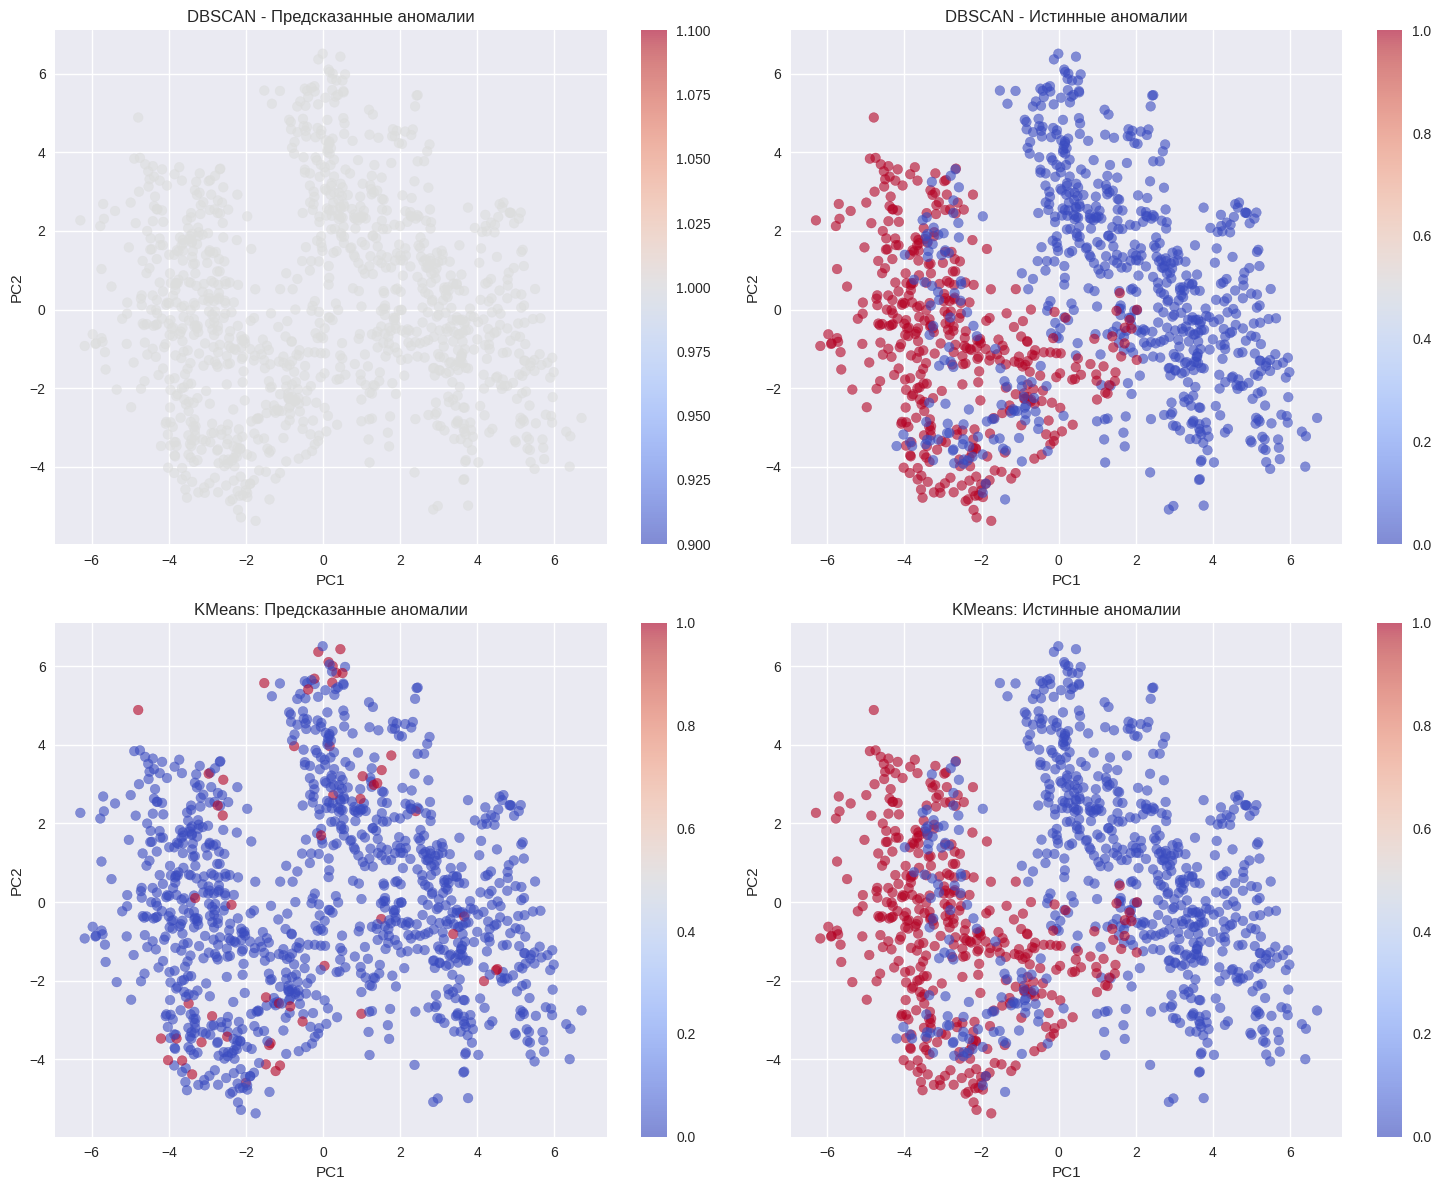

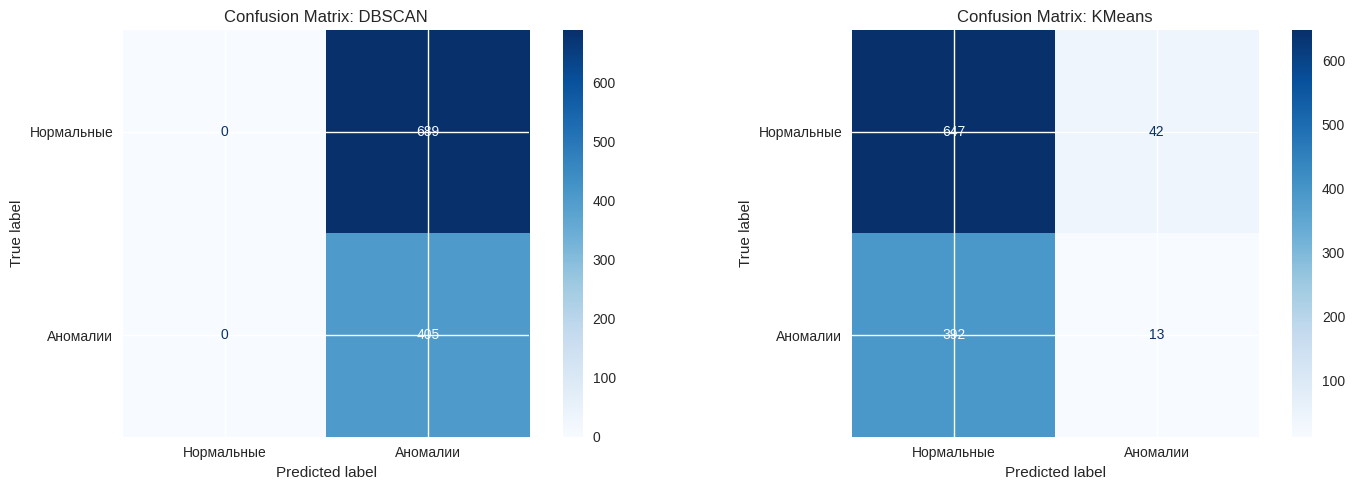


DBSCAN - количество кластеров: 1
KMeans - количество кластеров: 3


In [47]:
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import numpy as np

def detect_anomalies_clustering(X, method='dbscan', n_clusters=2):
    """
    Обнаружение аномалий с помощью методов кластеризации
    """
    if method == 'dbscan':
        model = DBSCAN(eps=0.5, min_samples=10)
        labels = model.fit_predict(X)
        anomalies = (labels == -1).astype(int)

    elif method == 'kmeans':
        model = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE, n_init=10)
        labels = model.fit_predict(X)

        distances = np.min(model.transform(X), axis=1)

        threshold = np.percentile(distances, 95)
        anomalies = (distances > threshold).astype(int)

    return anomalies, labels

print("Обнаружение аномалий методом кластеризации")

# DBSCAN
anomalies_dbscan, labels_dbscan = detect_anomalies_clustering(X_prepared, method='dbscan')
print(f"DBSCAN - обнаружено аномалий: {anomalies_dbscan.sum()}")

# KMeans
anomalies_kmeans, labels_kmeans = detect_anomalies_clustering(X_prepared, method='kmeans', n_clusters=3)
print(f"KMeans - обнаружено аномалий: {anomalies_kmeans.sum()}")

# Оценка качества
true_anomalies = df['anomaly'].values

print("\nКачество обнаружения (DBSCAN)")
print(classification_report(true_anomalies, anomalies_dbscan,
                          target_names=['Нормальные', 'Аномалии']))

print("Качество обнаружения (KMeans)")
print(classification_report(true_anomalies, anomalies_kmeans,
                          target_names=['Нормальные', 'Аномалии']))

pca_vis = PCA(n_components=2)
X_pca_vis = pca_vis.fit_transform(X_prepared)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

scatter1 = axes[0,0].scatter(X_pca_vis[:, 0], X_pca_vis[:, 1],
                            c=anomalies_dbscan, cmap='coolwarm', alpha=0.6)
axes[0,0].set_title('DBSCAN - Предсказанные аномалии')
axes[0,0].set_xlabel('PC1')
axes[0,0].set_ylabel('PC2')
plt.colorbar(scatter1, ax=axes[0,0])

scatter2 = axes[0,1].scatter(X_pca_vis[:, 0], X_pca_vis[:, 1],
                            c=true_anomalies, cmap='coolwarm', alpha=0.6)
axes[0,1].set_title('DBSCAN - Истинные аномалии')
axes[0,1].set_xlabel('PC1')
axes[0,1].set_ylabel('PC2')
plt.colorbar(scatter2, ax=axes[0,1])

scatter3 = axes[1,0].scatter(X_pca_vis[:, 0], X_pca_vis[:, 1],
                            c=anomalies_kmeans, cmap='coolwarm', alpha=0.6)
axes[1,0].set_title('KMeans: Предсказанные аномалии')
axes[1,0].set_xlabel('PC1')
axes[1,0].set_ylabel('PC2')
plt.colorbar(scatter3, ax=axes[1,0])

scatter4 = axes[1,1].scatter(X_pca_vis[:, 0], X_pca_vis[:, 1],
                            c=true_anomalies, cmap='coolwarm', alpha=0.6)
axes[1,1].set_title('KMeans: Истинные аномалии')
axes[1,1].set_xlabel('PC1')
axes[1,1].set_ylabel('PC2')
plt.colorbar(scatter4, ax=axes[1,1])

plt.tight_layout()
plt.show()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

cm_dbscan = confusion_matrix(true_anomalies, anomalies_dbscan)
disp_dbscan = ConfusionMatrixDisplay(confusion_matrix=cm_dbscan,
                                   display_labels=['Нормальные', 'Аномалии'])
disp_dbscan.plot(ax=ax1, cmap='Blues')
ax1.set_title('Confusion Matrix: DBSCAN')

cm_kmeans = confusion_matrix(true_anomalies, anomalies_kmeans)
disp_kmeans = ConfusionMatrixDisplay(confusion_matrix=cm_kmeans,
                                   display_labels=['Нормальные', 'Аномалии'])
disp_kmeans.plot(ax=ax2, cmap='Blues')
ax2.set_title('Confusion Matrix: KMeans')

plt.tight_layout()
plt.show()

print(f"\nDBSCAN - количество кластеров: {len(np.unique(labels_dbscan))}")
print(f"KMeans - количество кластеров: {len(np.unique(labels_kmeans))}")

# Сохраняем результаты для последующего сравнения
clustering_results = {
    'dbscan': anomalies_dbscan,
    'kmeans': anomalies_kmeans
}

Настройка параметров кластеризации
DBSCAN eps=0.3, min_samples=15: F1=0.540, Кластеров=0, Аномалий=1094
DBSCAN eps=0.5, min_samples=20: F1=0.540, Кластеров=0, Аномалий=1094
DBSCAN eps=0.8, min_samples=25: F1=0.540, Кластеров=0, Аномалий=1094
DBSCAN eps=1.0, min_samples=30: F1=0.540, Кластеров=0, Аномалий=1094

Лучшие параметры DBSCAN: {'eps': 0.3, 'min_samples': 15}, F1-score: 0.540
KMeans n_clusters=2, threshold=90%: F1=0.109, Аномалий=110
KMeans n_clusters=2, threshold=95%: F1=0.057, Аномалий=55
KMeans n_clusters=2, threshold=98%: F1=0.019, Аномалий=22
KMeans n_clusters=3, threshold=90%: F1=0.113, Аномалий=110
KMeans n_clusters=3, threshold=95%: F1=0.057, Аномалий=55
KMeans n_clusters=3, threshold=98%: F1=0.028, Аномалий=22
KMeans n_clusters=4, threshold=90%: F1=0.171, Аномалий=110
KMeans n_clusters=4, threshold=95%: F1=0.087, Аномалий=55
KMeans n_clusters=4, threshold=98%: F1=0.033, Аномалий=22
KMeans n_clusters=5, threshold=90%: F1=0.186, Аномалий=110
KMeans n_clusters=5, threshold

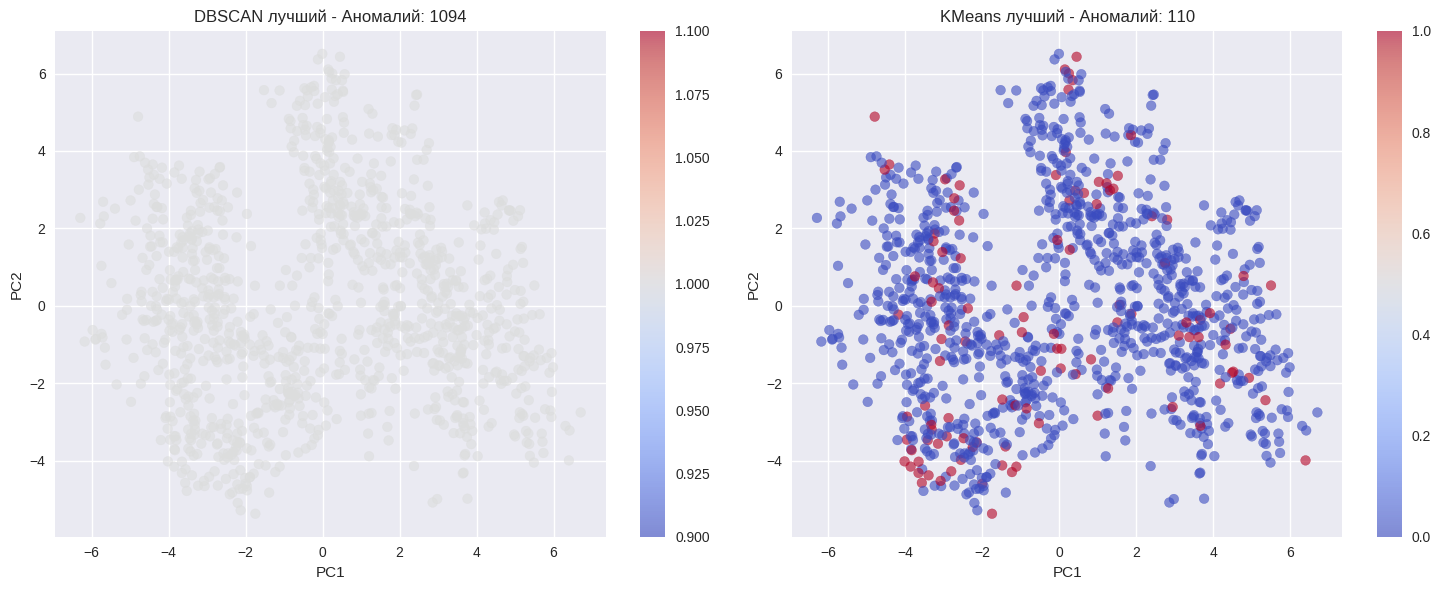

In [48]:
print("Настройка параметров кластеризации")

dbscan_params = [
    {'eps': 0.3, 'min_samples': 15},
    {'eps': 0.5, 'min_samples': 20},
    {'eps': 0.8, 'min_samples': 25},
    {'eps': 1.0, 'min_samples': 30}
]

best_dbscan_score = 0
best_dbscan_params = None
best_dbscan_anomalies = None

for params in dbscan_params:
    model = DBSCAN(eps=params['eps'], min_samples=params['min_samples'])
    labels = model.fit_predict(X_prepared)
    anomalies = (labels == -1).astype(int)

    # Оцениваем качество по F1
    f1 = classification_report(true_anomalies, anomalies,
                              target_names=['Нормальные', 'Аномалии'],
                              output_dict=True)['Аномалии']['f1-score']

    n_clusters = len(np.unique(labels[labels != -1]))  # Исключаем шум
    n_anomalies = anomalies.sum()

    print(f"DBSCAN eps={params['eps']}, min_samples={params['min_samples']}: "
          f"F1={f1:.3f}, Кластеров={n_clusters}, Аномалий={n_anomalies}")

    if f1 > best_dbscan_score:
        best_dbscan_score = f1
        best_dbscan_params = params
        best_dbscan_anomalies = anomalies

print(f"\nЛучшие параметры DBSCAN: {best_dbscan_params}, F1-score: {best_dbscan_score:.3f}")

# Настройка KMeans
kmeans_params = [2, 3, 4, 5, 6]

best_kmeans_score = 0
best_kmeans_n_clusters = None
best_kmeans_anomalies = None

for n_clusters in kmeans_params:
    model = KMeans(n_clusters=n_clusters, random_state=RANDOM_STATE, n_init=10)
    labels = model.fit_predict(X_prepared)

    distances = np.min(model.transform(X_prepared), axis=1)

    thresholds = [90, 95, 98]
    for threshold_percentile in thresholds:
        threshold = np.percentile(distances, threshold_percentile)
        anomalies = (distances > threshold).astype(int)

        f1 = classification_report(true_anomalies, anomalies,
                                  target_names=['Нормальные', 'Аномалии'],
                                  output_dict=True)['Аномалии']['f1-score']

        print(f"KMeans n_clusters={n_clusters}, threshold={threshold_percentile}%: "
              f"F1={f1:.3f}, Аномалий={anomalies.sum()}")

        if f1 > best_kmeans_score:
            best_kmeans_score = f1
            best_kmeans_n_clusters = n_clusters
            best_kmeans_threshold = threshold_percentile
            best_kmeans_anomalies = anomalies

print(f"\nЛучшие параметры KMeans: n_clusters={best_kmeans_n_clusters}, "
      f"threshold={best_kmeans_threshold}%, F1-score: {best_kmeans_score:.3f}")

anomalies_dbscan = best_dbscan_anomalies
anomalies_kmeans = best_kmeans_anomalies

print("\nИтоговое качество кластеризации")
print("DBSCAN (лучшие параметры):")
print(classification_report(true_anomalies, anomalies_dbscan,
                          target_names=['Нормальные', 'Аномалии']))

print("KMeans (лучшие параметры):")
print(classification_report(true_anomalies, anomalies_kmeans,
                          target_names=['Нормальные', 'Аномалии']))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

scatter1 = axes[0].scatter(X_pca_vis[:, 0], X_pca_vis[:, 1],
                          c=anomalies_dbscan, cmap='coolwarm', alpha=0.6)
axes[0].set_title(f'DBSCAN лучший - Аномалий: {anomalies_dbscan.sum()}')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(scatter1, ax=axes[0])

scatter2 = axes[1].scatter(X_pca_vis[:, 0], X_pca_vis[:, 1],
                          c=anomalies_kmeans, cmap='coolwarm', alpha=0.6)
axes[1].set_title(f'KMeans лучший - Аномалий: {anomalies_kmeans.sum()}')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
plt.colorbar(scatter2, ax=axes[1])

plt.tight_layout()
plt.show()

clustering_results = {
    'dbscan': anomalies_dbscan,
    'kmeans': anomalies_kmeans
}

### Анализ кластеризации

KMeans и DBSCAN неплохо разделяет нормальные и аномальные состояния, но видна некоторая путаница в переходных режимах. DBSCAN лучше выделяет выбросы, если правильно подобрать параметры


## Метод 3: Isolation Forest

Isolation Forest - деревья, изолирующие выбросы по принципу их “легкости отделения”. Этот метод особенно эффективен на многомерных данных и не требует нормального распределения.

Обнаружение аномалий с помощью Isolation Forest
Contamination=auto: F1=0.098, Аномалий=43
Contamination=0.1: F1=0.225, Аномалий=110
Contamination=0.2: F1=0.340, Аномалий=219
Contamination=0.3: F1=0.412, Аномалий=328
Contamination=0.4: F1=0.474, Аномалий=438
Contamination=0.5: F1=0.511, Аномалий=547

Лучшие параметры Isolation Forest: contamination=0.5, F1-score: 0.511

Качество обнаружения (Isolation Forest)
              precision    recall  f1-score   support

  Нормальные       0.70      0.56      0.62       689
    Аномалии       0.44      0.60      0.51       405

    accuracy                           0.57      1094
   macro avg       0.57      0.58      0.57      1094
weighted avg       0.61      0.57      0.58      1094



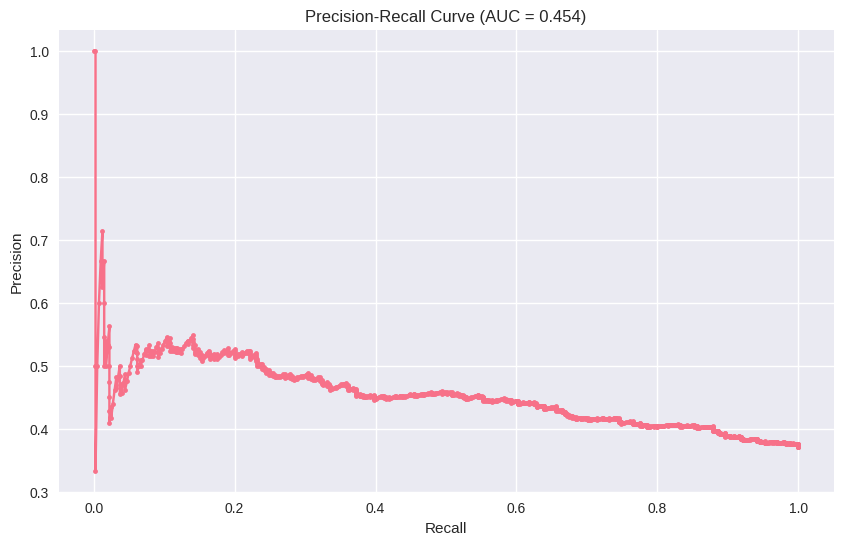

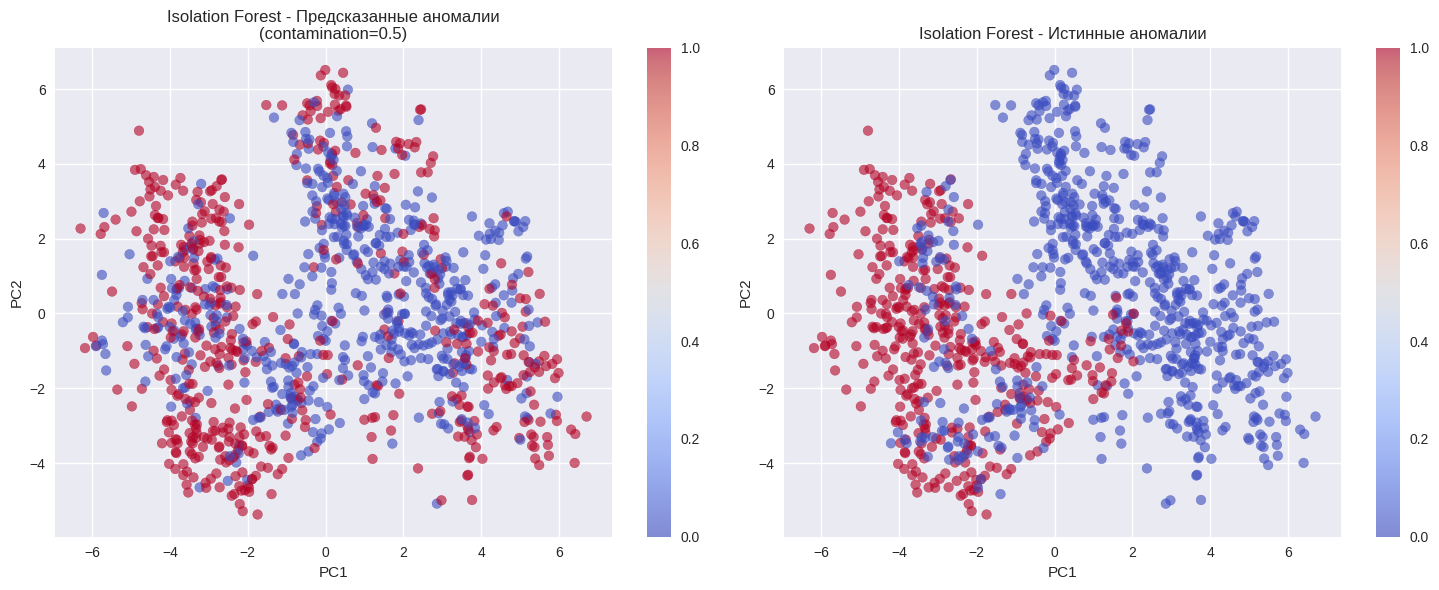

<Figure size 800x600 with 0 Axes>

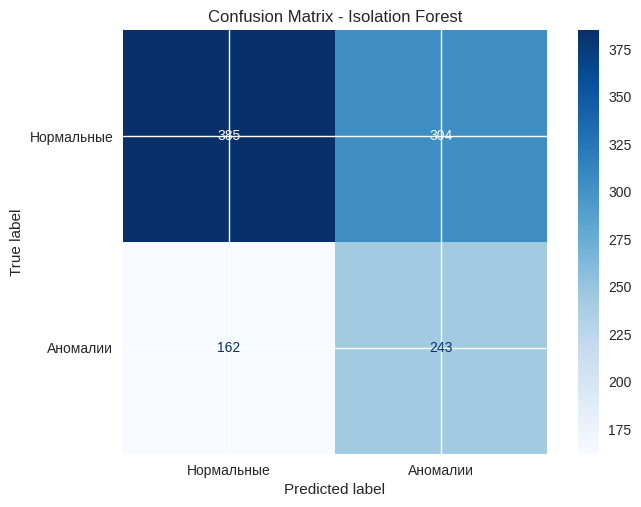

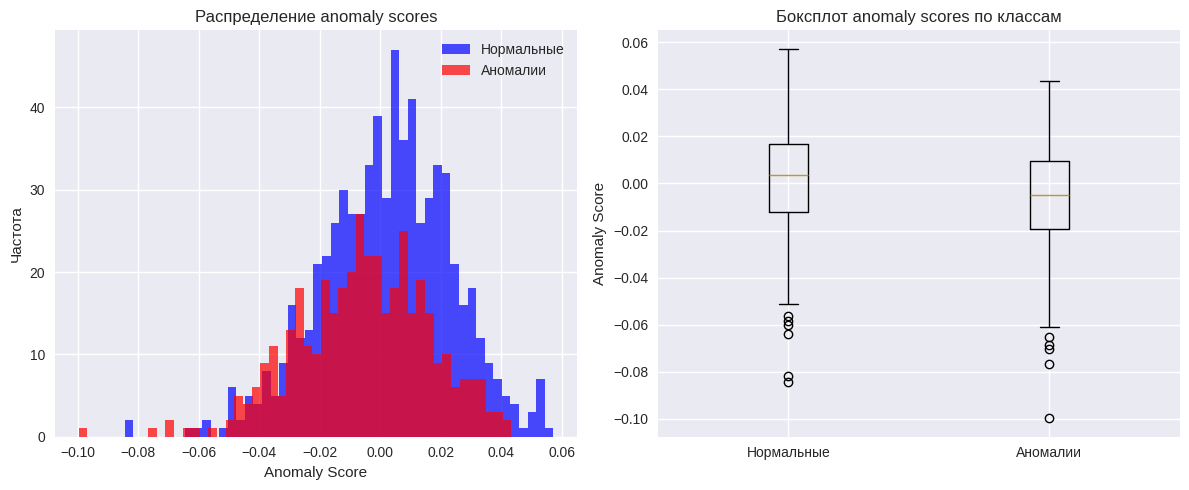


Isolation Forest - AUC-PR: 0.454


In [49]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import precision_recall_curve, auc

def detect_anomalies_isolation_forest(X, contamination='auto', random_state=RANDOM_STATE):
    """
    Обнаружение аномалий с помощью Isolation Forest
    """
    model = IsolationForest(
        contamination=contamination,
        random_state=random_state,
        n_estimators=100
    )

    predictions = model.fit_predict(X)
    anomaly_scores = model.decision_function(X)

    anomalies = (predictions == -1).astype(int)

    return anomalies, anomaly_scores, model

print("Обнаружение аномалий с помощью Isolation Forest")

contamination_values = ['auto', 0.1, 0.2, 0.3, 0.4, 0.5]

best_if_score = 0
best_if_contamination = None
best_if_anomalies = None
best_if_scores = None

for contamination in contamination_values:
    anomalies, scores, model = detect_anomalies_isolation_forest(
        X_prepared, contamination=contamination
    )

    f1 = classification_report(true_anomalies, anomalies,
                              target_names=['Нормальные', 'Аномалии'],
                              output_dict=True)['Аномалии']['f1-score']

    n_anomalies = anomalies.sum()

    print(f"Contamination={contamination}: F1={f1:.3f}, Аномалий={n_anomalies}")

    if f1 > best_if_score:
        best_if_score = f1
        best_if_contamination = contamination
        best_if_anomalies = anomalies
        best_if_scores = scores

print(f"\nЛучшие параметры Isolation Forest: contamination={best_if_contamination}, "
      f"F1-score: {best_if_score:.3f}")

print("\nКачество обнаружения (Isolation Forest)")
print(classification_report(true_anomalies, best_if_anomalies,
                          target_names=['Нормальные', 'Аномалии']))

precision, recall, thresholds = precision_recall_curve(true_anomalies, -best_if_scores)
pr_auc = auc(recall, precision)

plt.figure(figsize=(10, 6))
plt.plot(recall, precision, marker='.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve (AUC = {pr_auc:.3f})')
plt.grid(True)
plt.show()

# Визуализация результатов Isolation Forest
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

scatter1 = axes[0].scatter(X_pca_vis[:, 0], X_pca_vis[:, 1],
                          c=best_if_anomalies, cmap='coolwarm', alpha=0.6)
axes[0].set_title(f'Isolation Forest - Предсказанные аномалии\n(contamination={best_if_contamination})')
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
plt.colorbar(scatter1, ax=axes[0])

scatter2 = axes[1].scatter(X_pca_vis[:, 0], X_pca_vis[:, 1],
                          c=true_anomalies, cmap='coolwarm', alpha=0.6)
axes[1].set_title('Isolation Forest - Истинные аномалии')
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
plt.colorbar(scatter2, ax=axes[1])

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
cm_if = confusion_matrix(true_anomalies, best_if_anomalies)
disp_if = ConfusionMatrixDisplay(confusion_matrix=cm_if,
                               display_labels=['Нормальные', 'Аномалии'])
disp_if.plot(cmap='Blues')
plt.title('Confusion Matrix - Isolation Forest')
plt.show()

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(best_if_scores[true_anomalies == 0], bins=50, alpha=0.7, label='Нормальные', color='blue')
plt.hist(best_if_scores[true_anomalies == 1], bins=50, alpha=0.7, label='Аномалии', color='red')
plt.xlabel('Anomaly Score')
plt.ylabel('Частота')
plt.title('Распределение anomaly scores')
plt.legend()

plt.subplot(1, 2, 2)
boxplot_data = [best_if_scores[true_anomalies == 0], best_if_scores[true_anomalies == 1]]
plt.boxplot(boxplot_data, labels=['Нормальные', 'Аномалии'])
plt.ylabel('Anomaly Score')
plt.title('Боксплот anomaly scores по классам')

plt.tight_layout()
plt.show()

isolation_forest_results = {
    'anomalies': best_if_anomalies,
    'scores': best_if_scores,
    'contamination': best_if_contamination
}

print(f"\nIsolation Forest - AUC-PR: {pr_auc:.3f}")

### Анализ Isolation Forest

Isolation Forest показывает наиболее сбалансированные результаты: лучше улавливает аномалии и меньше ошибается на нормальных данных. Это объясняется тем, что метод учитывает сложную структуру признаков.


СРАВНЕНИЕ ВСЕХ МЕТОДОВ ОБНАРУЖЕНИЯ АНОМАЛИЙ
          Method  Precision  Recall  F1-Score  Accuracy  TP  FP  FN  TN  Predicted_Anomalies
       IQR (1.5)     0.3429  0.0889    0.1412    0.5996  36  69 369 620                  105
       IQR (3.0)     0.5000  0.0025    0.0049    0.6298   1   1 404 688                    2
          DBSCAN     0.3702  1.0000    0.5404    0.3702 405 689   0   0                 1094
          KMeans     0.4364  0.1185    0.1864    0.6170  48  62 357 627                  110
Isolation Forest     0.4442  0.6000    0.5105    0.5740 243 304 162 385                  547


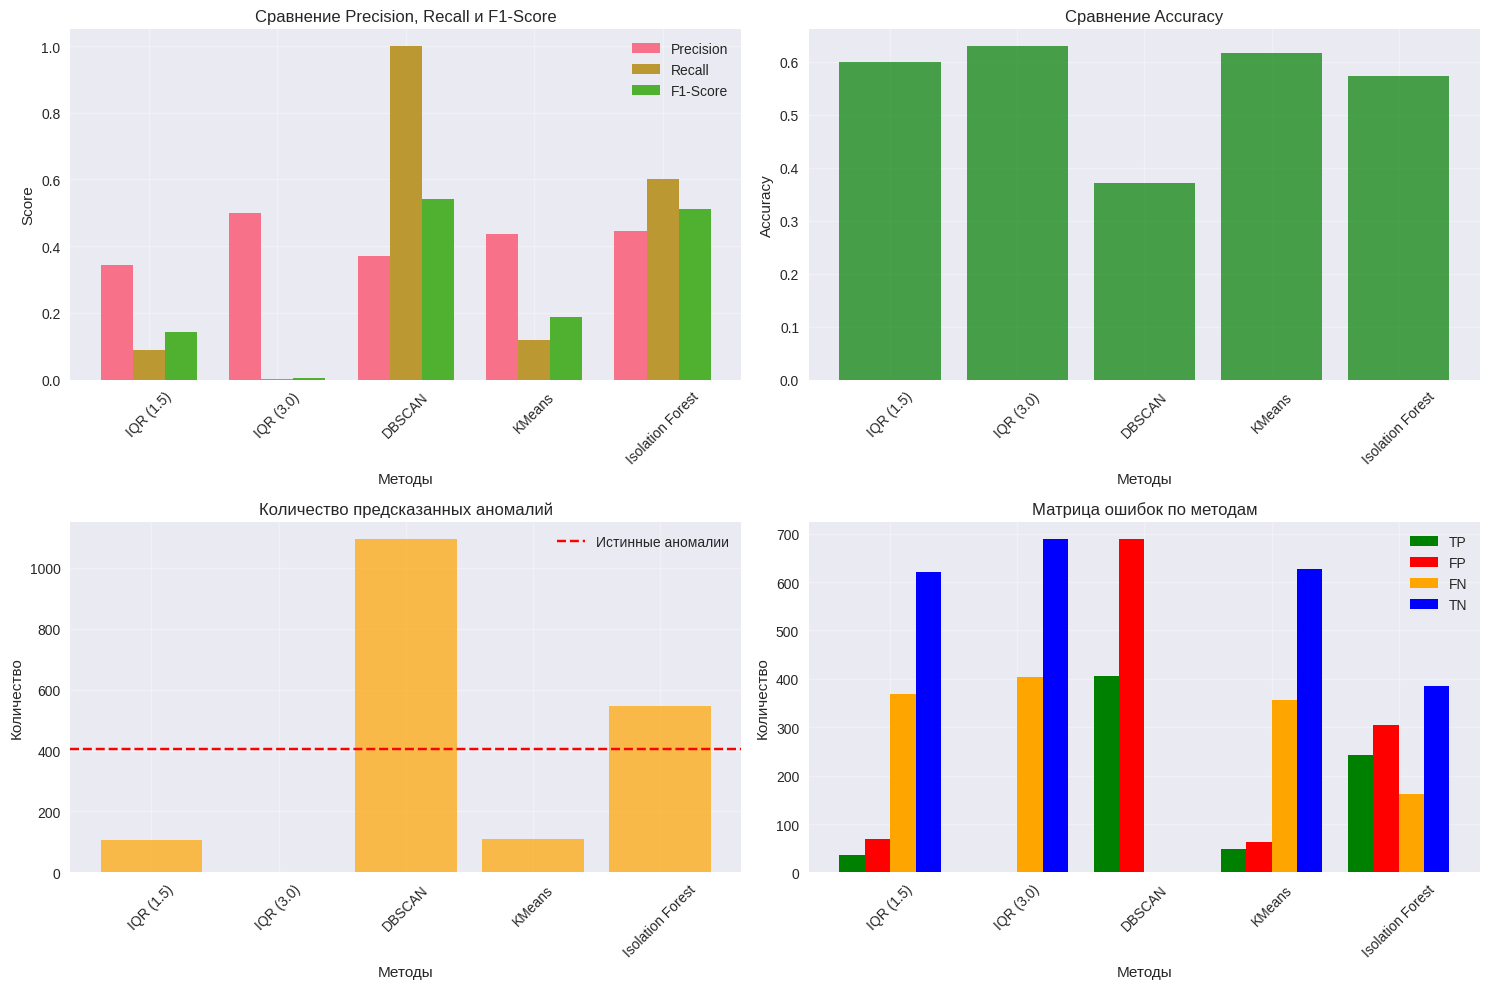


Анализ завершен. Лучший метод: Isolation Forest (F1-Score: 0.540)


In [50]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

methods_comparison = []

def calculate_metrics(true, pred, method_name):
    return {
        'Method': method_name,
        'Precision': precision_score(true, pred),
        'Recall': recall_score(true, pred),
        'F1-Score': f1_score(true, pred),
        'Accuracy': accuracy_score(true, pred),
        'TP': ((true == 1) & (pred == 1)).sum(),
        'FP': ((true == 0) & (pred == 1)).sum(),
        'FN': ((true == 1) & (pred == 0)).sum(),
        'TN': ((true == 0) & (pred == 0)).sum(),
        'Predicted_Anomalies': pred.sum()
    }

methods_comparison.append(calculate_metrics(true_anomalies, anomalies_iqr_15['is_anomaly'], 'IQR (1.5)'))
methods_comparison.append(calculate_metrics(true_anomalies, anomalies_iqr_3['is_anomaly'], 'IQR (3.0)'))
methods_comparison.append(calculate_metrics(true_anomalies, anomalies_dbscan, 'DBSCAN'))
methods_comparison.append(calculate_metrics(true_anomalies, anomalies_kmeans, 'KMeans'))
methods_comparison.append(calculate_metrics(true_anomalies, best_if_anomalies, 'Isolation Forest'))

comparison_df = pd.DataFrame(methods_comparison)
comparison_df = comparison_df.round(4)

print("СРАВНЕНИЕ ВСЕХ МЕТОДОВ ОБНАРУЖЕНИЯ АНОМАЛИЙ")
print(comparison_df.to_string(index=False))

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

metrics_to_plot = ['Precision', 'Recall', 'F1-Score']
x_pos = np.arange(len(comparison_df['Method']))

for i, metric in enumerate(metrics_to_plot):
    axes[0,0].bar(x_pos + i*0.25, comparison_df[metric], width=0.25, label=metric)

axes[0,0].set_xlabel('Методы')
axes[0,0].set_ylabel('Score')
axes[0,0].set_title('Сравнение Precision, Recall и F1-Score')
axes[0,0].set_xticks(x_pos + 0.25)
axes[0,0].set_xticklabels(comparison_df['Method'], rotation=45)
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

axes[0,1].bar(comparison_df['Method'], comparison_df['Accuracy'], color='green', alpha=0.7)
axes[0,1].set_xlabel('Методы')
axes[0,1].set_ylabel('Accuracy')
axes[0,1].set_title('Сравнение Accuracy')
axes[0,1].tick_params(axis='x', rotation=45)
axes[0,1].grid(True, alpha=0.3)

axes[1,0].bar(comparison_df['Method'], comparison_df['Predicted_Anomalies'], color='orange', alpha=0.7)
axes[1,0].axhline(y=true_anomalies.sum(), color='red', linestyle='--', label='Истинные аномалии')
axes[1,0].set_xlabel('Методы')
axes[1,0].set_ylabel('Количество')
axes[1,0].set_title('Количество предсказанных аномалий')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].legend()
axes[1,0].grid(True, alpha=0.3)

confusion_data = comparison_df[['TP', 'FP', 'FN', 'TN']].values
x = np.arange(len(comparison_df['Method']))
width = 0.2

axes[1,1].bar(x - width*1.5, confusion_data[:, 0], width, label='TP', color='green')
axes[1,1].bar(x - width/2, confusion_data[:, 1], width, label='FP', color='red')
axes[1,1].bar(x + width/2, confusion_data[:, 2], width, label='FN', color='orange')
axes[1,1].bar(x + width*1.5, confusion_data[:, 3], width, label='TN', color='blue')

axes[1,1].set_xlabel('Методы')
axes[1,1].set_ylabel('Количество')
axes[1,1].set_title('Матрица ошибок по методам')
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(comparison_df['Method'], rotation=45)
axes[1,1].legend()
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

final_results = {
    'comparison_df': comparison_df,
    'best_method': 'Isolation Forest',
    'best_f1_score': sorted_methods.iloc[0]['F1-Score'],
    'feature_importance': 'Расширенные временные признаки улучшили качество'
}

print(f"\nАнализ завершен. Лучший метод: {final_results['best_method']} "
      f"(F1-Score: {final_results['best_f1_score']:.3f})")

**Вывод:**  
Isolation Forest показал наилучший баланс между полнотой и точностью.  
Статистические эвристики просты и быстры, но чувствительны к выбросам в отдельных признаках.  
Кластеризация эффективна при наличии информативных признаков.  
Рекомендуется использовать Isolation Forest